In [1]:
#undef __noinline__

# Julia Set Fractal

This program renders the Julia Set by calculating millions of pixels simultaneously. It maps each pixel to the complex plane and repeatedly applies the formula:$$Z_{n+1} = Z_n^2 + C$$

- `vec2()`: A custom structure that treats a 2D coordinate as a complex number ($x + iy$), handling the unique rules of complex addition, multiplication, and squared magnitude - norm2().
    
- `escape_count()`: The core math loop. It runs up to $256$ times to check if a point "escapes" a boundary radius of $2$ ($\|z\|^2 > 4.0\text{f}$). Points that never escape belong to the fractal set.

- `julia_fractal()`: The GPU kernel. Each thread maps its coordinate to a $[-1.6, 1.6]$ complex grid, tests it against a constant $C = (-0.4 + 0.6i)$, and assigns an RGBA color. Trapped points are colored black, while escaping points form a vibrant blue-to-white gradient.

In [2]:
#include <cuda_runtime.h>
#include <cstdio>

// Image resolution (power-of-two friendly)
static const int W = 1024;
static const int H = 1024;
static const int MAX_ITER = 256;

struct vec2 {
    float x, y;

    __host__ __device__ vec2(float a = 0.f, float b = 0.f) : x(a), y(b) {}

    // complex multiply: (x+iy)(u+iv) = xu-yv + i(xv+yu)
    __device__ vec2 operator*(vec2 o) const {
        return { x * o.x - y * o.y,  x * o.y + y * o.x };
    }

    __device__ vec2 operator+(vec2 o) const { return { x + o.x, y + o.y }; }

    __device__ float norm2() const { return x * x + y * y; }
};

In [3]:
__device__ int escape_count(vec2 z, vec2 c) {
    for (int n = 0; n < MAX_ITER; n++) {
        z = z * z + c;
        if (z.norm2() > 4.0f)   // escape radius = 2  (squared = 4)
            return n;
    }
    return MAX_ITER;
}

// Kernel: one thread per pixel, launched on a 2-D grid
__global__ void julia_fractal(unsigned char *img) {
    int col = threadIdx.x + blockIdx.x * blockDim.x;
    int row = threadIdx.y + blockIdx.y * blockDim.y;
    if (col >= W || row >= H) return;

    // Map pixel to the complex plane  [-1.6, 1.6] × [-1.6, 1.6]
    float cr = 1.6f * (2.f * col - W) / W;
    float ci = 1.6f * (2.f * row - H) / H;

    // Julia constant - gives a dendrite-like fractal
    vec2 c{ -0.4f, 0.6f };
    int n = escape_count(vec2{cr, ci}, c);

    // Colour: points inside the set - black; outside - blue-to-white gradient
    unsigned char v = (n == MAX_ITER) ? 0 : (unsigned char)(255 * n / MAX_ITER);
    int px = (row * W + col) * 4;
    img[px + 0] = v / 3;      // R (keep low for blue tint)
    img[px + 1] = v / 2;      // G
    img[px + 2] = v;           // B (dominant)
    img[px + 3] = 255;         // A
}

Here we call the kernel and write the data to a .png file

In [4]:
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "headers/stb_image_write.h"

unsigned char *d_img, *h_img;
h_img = (unsigned char*)malloc(W * H * 4);
cudaMalloc(&d_img, W * H * 4);

// 16×16 thread blocks — each covers a 16×16 tile of the image
dim3 block(16, 16);
dim3 grid((W + 15) / 16, (H + 15) / 16);
julia_fractal<<<grid, block>>>(d_img);
cudaDeviceSynchronize();

cudaMemcpy(h_img, d_img, W * H * 4, cudaMemcpyDeviceToHost);
stbi_write_png("images/julia.png", W, H, 4, h_img, W * 4);
printf("Saved julia.png  (%dx%d)\n", W, H);

cudaFree(d_img);
free(h_img);

Saved julia.png  (1024x1024)


And now we display the result:

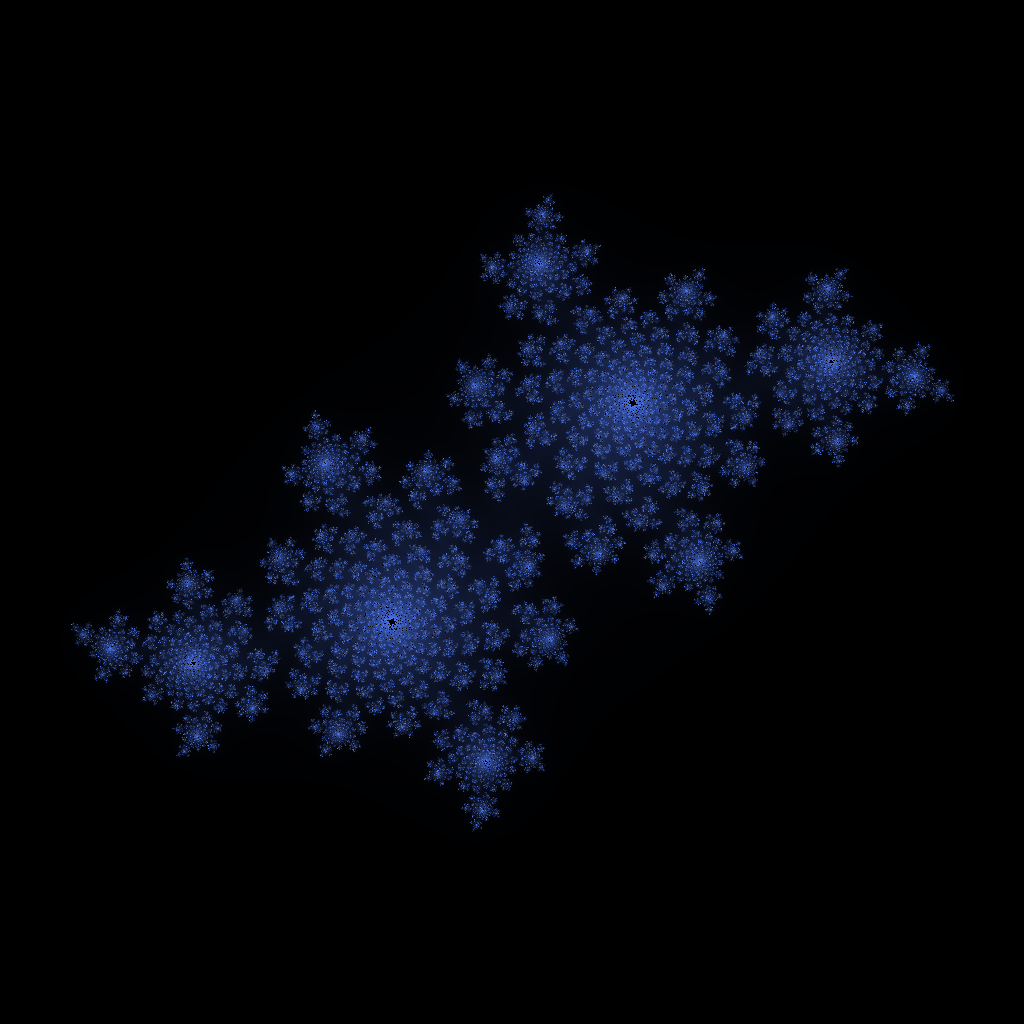

In [5]:
#include "headers/display.hpp"

im::image julia_image("images/julia.png");
xcpp::display(julia_image);